## About this project
Loan default is always the threat to any financial institution and should be predicted in advance based on various features of the applicant. This study aims at applying machine models, including decision tree, logistic regression, svm and random forest to classify applicants with and without loan default from a group of predicting variables, and evaluate their performance.

In [2]:
import sys
!{sys.executable} -m pip install pydotplus

## Machine learning issue and objectives

We're dealing with supervised binary classification problem. The goal is to train the best machine learning model to maximize the predictive capability of the past customer's profile minimizing the risk of future loan defaults.

## Performance Metric

The metric used for the model's evaluation is the F1 score

## Project Structure

The project divides into three categories:
1. EDA: Exploratory Data Anlysis.
2. Data Wrangling: Cleansing and Feature Selection.
3. Machine Learning: Predictive Modelling.

# The Dataset
## Feature Description
1. id: Unique ID of the loan application.
2. grade: LC assigned loan grade.
3. annual_inc: The self-reported annual income provided by the borrower during registration.
4. short_emp: 1 when employed for 1 year or less.
5. emp_length_len: Employment lengths in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years.
6. home_ownership: Type of home ownership.
7. dti(Debt-to-Income Ratio): A ratio calculated using borrower's total monthly payments on the total debt obligations, excluding mortage and requested LC loan, divided by borrower's self-reported monthly income.
8. purpose: A category provided by the borrower for the loan request.
9. term: The number of payments on the loan. Values are in months and can be either 36 or 60.
10. last_delinq_none: 1 when the borrower had at least one event of delinquency.
11. last_major_derog_none: 1 if borrower had at least 90 days of bad rating.
12. revol_util: Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit.
13. total_rec_late_fee: Late fees recieved to date.
14. bad_loan: 1 when a loan was not paid.


## Importing libraries and dependencies

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns

import scipy
from scipy.stats import chi2
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr, spearmanr

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn import tree
from sklearn.tree import export_graphviz

from six import StringIO
from sklearn.metrics import precision_recall_curve, roc_auc_score, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, auc, roc_curve
# from category_encoders.binary import BinaryEncoder
from IPython.display import Image
import pydotplus

import matplotlib.pyplot as plt
%matplotlib inline
color = sns.color_palette()

seed = 42

In [9]:
data = pd.read_csv('tata_dataset.csv', low_memory = False)

In [10]:
data.head()

,id,grade,annual_inc,short_emp,emp_length_num,home_ownership,dti,purpose,term,last_delinq_none,last_major_derog_none,revol_util,total_rec_late_fee,od_ratio,bad_loan
0,11454641,A,100000.0,1,1,RENT,26.27,credit_card,36 months,1,NaN,43.2,0.0,0.160624,0
1,9604874,A,83000.0,0,4,OWN,5.39,credit_card,36 months,0,NaN,21.5,0.0,0.810777,0
2,9684700,D,78000.0,0,11,MORTGAGE,18.45,debt_consolidation,60 months,1,NaN,46.3,0.0,0.035147,1
3,9695736,D,37536.0,0,6,MORTGAGE,12.28,medical,60 months,0,NaN,10.7,0.0,0.534887,1
4,9795013,D,65000.0,0,11,MORTGAGE,11.26,debt_consolidation,36 months,0,NaN,15.2,0.0,0.166500,0


# EDA: Exploraotory Data Analysis

In [12]:
data.shape

(20000, 15)

Main stats of numeric attributes

In [14]:
data.describe()

,id,annual_inc,short_emp,emp_length_num,dti,last_delinq_none,last_major_derog_none,revol_util,total_rec_late_fee,od_ratio,bad_loan
count,2.000000e+04,20000.000000,20000.000000,20000.00000,19846.000000,20000.000000,574.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,7.590662e+06,73349.578350,0.112500,6.82140,16.587841,0.546600,0.759582,55.958148,0.290622,0.504430,0.20000
std,1.609593e+06,45198.567255,0.315989,3.77423,7.585812,0.497836,0.427710,42.117456,3.108654,0.287720,0.40001
min,5.860400e+05,8412.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000077,0.00000
25%,6.206283e+06,47000.000000,0.000000,3.00000,10.852500,0.000000,1.000000,38.800000,0.000000,0.257356,0.00000
50%,7.378896e+06,65000.000000,0.000000,7.00000,16.190000,1.000000,1.000000,57.100000,0.000000,0.506681,0.00000
75%,8.766235e+06,88000.000000,0.000000,11.00000,22.060000,1.000000,1.000000,73.900000,0.000000,0.753771,0.00000
max,1.145464e+07,1000000.000000,1.000000,11.00000,34.990000,1.000000,1.000000,5010.000000,96.466600,0.999894,1.00000


In [15]:
data.dtypes

id                         int64
grade                     object
annual_inc               float64
short_emp                  int64
emp_length_num             int64
home_ownership            object
dti                      float64
purpose                   object
term                      object
last_delinq_none           int64
last_major_derog_none    float64
revol_util               float64
total_rec_late_fee       float64
od_ratio                 float64
bad_loan                   int64
dtype: object

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     20000 non-null  int64  
 1   grade                  20000 non-null  object 
 2   annual_inc             20000 non-null  float64
 3   short_emp              20000 non-null  int64  
 4   emp_length_num         20000 non-null  int64  
 5   home_ownership         18509 non-null  object 
 6   dti                    19846 non-null  float64
 7   purpose                20000 non-null  object 
 8   term                   20000 non-null  object 
 9   last_delinq_none       20000 non-null  int64  
 10  last_major_derog_none  574 non-null    float64
 11  revol_util             20000 non-null  float64
 12  total_rec_late_fee     20000 non-null  float64
 13  od_ratio               20000 non-null  float64
 14  bad_loan               20000 non-null  int64  
dtypes:

In [17]:
data.isnull().mean() * 100

id                        0.000
grade                     0.000
annual_inc                0.000
short_emp                 0.000
emp_length_num            0.000
home_ownership            7.455
dti                       0.770
purpose                   0.000
term                      0.000
last_delinq_none          0.000
last_major_derog_none    97.130
revol_util                0.000
total_rec_late_fee        0.000
od_ratio                  0.000
bad_loan                  0.000
dtype: float64

The dataset has 20000 observations and 15 variables including the target, divided into 11 numeric and 4 categorical features.
There are variables with missing values: 'home_ownership' with 7.46%, 'dti' with 0.77%, and 'last_major_derog_none' with 97.13%.
From the difference between the mean and the median, and also the distance of maximum values of the variables 'annual_inc', 'revol_util' and 'total_rec_fee', it seems there are some outliers.

In [19]:
data.drop(['last_major_derog_none'], axis = 1, inplace = True)

In [20]:
num_cols = data.select_dtypes(include = 'number')
print(list(num_cols))
print(list(set(data.columns) - set(num_cols)))

['id', 'annual_inc', 'short_emp', 'emp_length_num', 'dti', 'last_delinq_none', 'revol_util', 'total_rec_late_fee', 'od_ratio', 'bad_loan']
['home_ownership', 'grade', 'term', 'purpose']


## Main stats of categorical attributes

In [22]:
data.describe(include = [object])

,grade,home_ownership,purpose,term
count,20000,18509,20000,20000
unique,7,3,12,3
top,B,MORTGAGE,debt_consolidation,36 months
freq,6042,9844,12337,14969


## Checking data balance/proportion

In [24]:
data.bad_loan.value_counts()/data.bad_loan.value_counts().sum()*100

bad_loan
0    80.0
1    20.0
Name: count, dtype: float64

**Unbalanced Data:** target has 20% of default results (value 1) against 80% of loans that ended up by been paid/non-default (value 0)

## EDA Functions
Describing all the features in the dataset using and abusing graphics. Start a few functions for every chart: boxplot, histogram, bar and pie charts, scatterplot. pivot chart, as well as statistis descriptions.

In [27]:
import warnings
def target(x):
    short_0 = data[data.bad_loan == 0].loc[:,x]   # it means to select all rows of column x where bad_loan is 0
    short_1 = data[data.bad_loan == 1].loc[:,x]   # it means to select all rows of column x where bad_loan is 1

    a = np.array(short_0)
    b = np.array(short_1)

    
    warnings.filterwarnings('ignore')

    plt.figure(figsize=(20, 5))

    plt.hist(a, bins=40, density=True, color="g", alpha = 0.6, label='Not-default', align="left")
    plt.hist(b, bins=40, density=True, color="r", alpha = 0.6, label='Default', align="right")
    plt.legend(loc='upper right')
    plt.title(x, fontsize=10, loc="right")
    plt.xlabel(x)
    plt.ylabel('Relative frequency')
    plt.show()



In [28]:
print(data['annual_inc'].min(), data['annual_inc'].max())


8412.0 1000000.0


## Visualization of the Numeric Variables

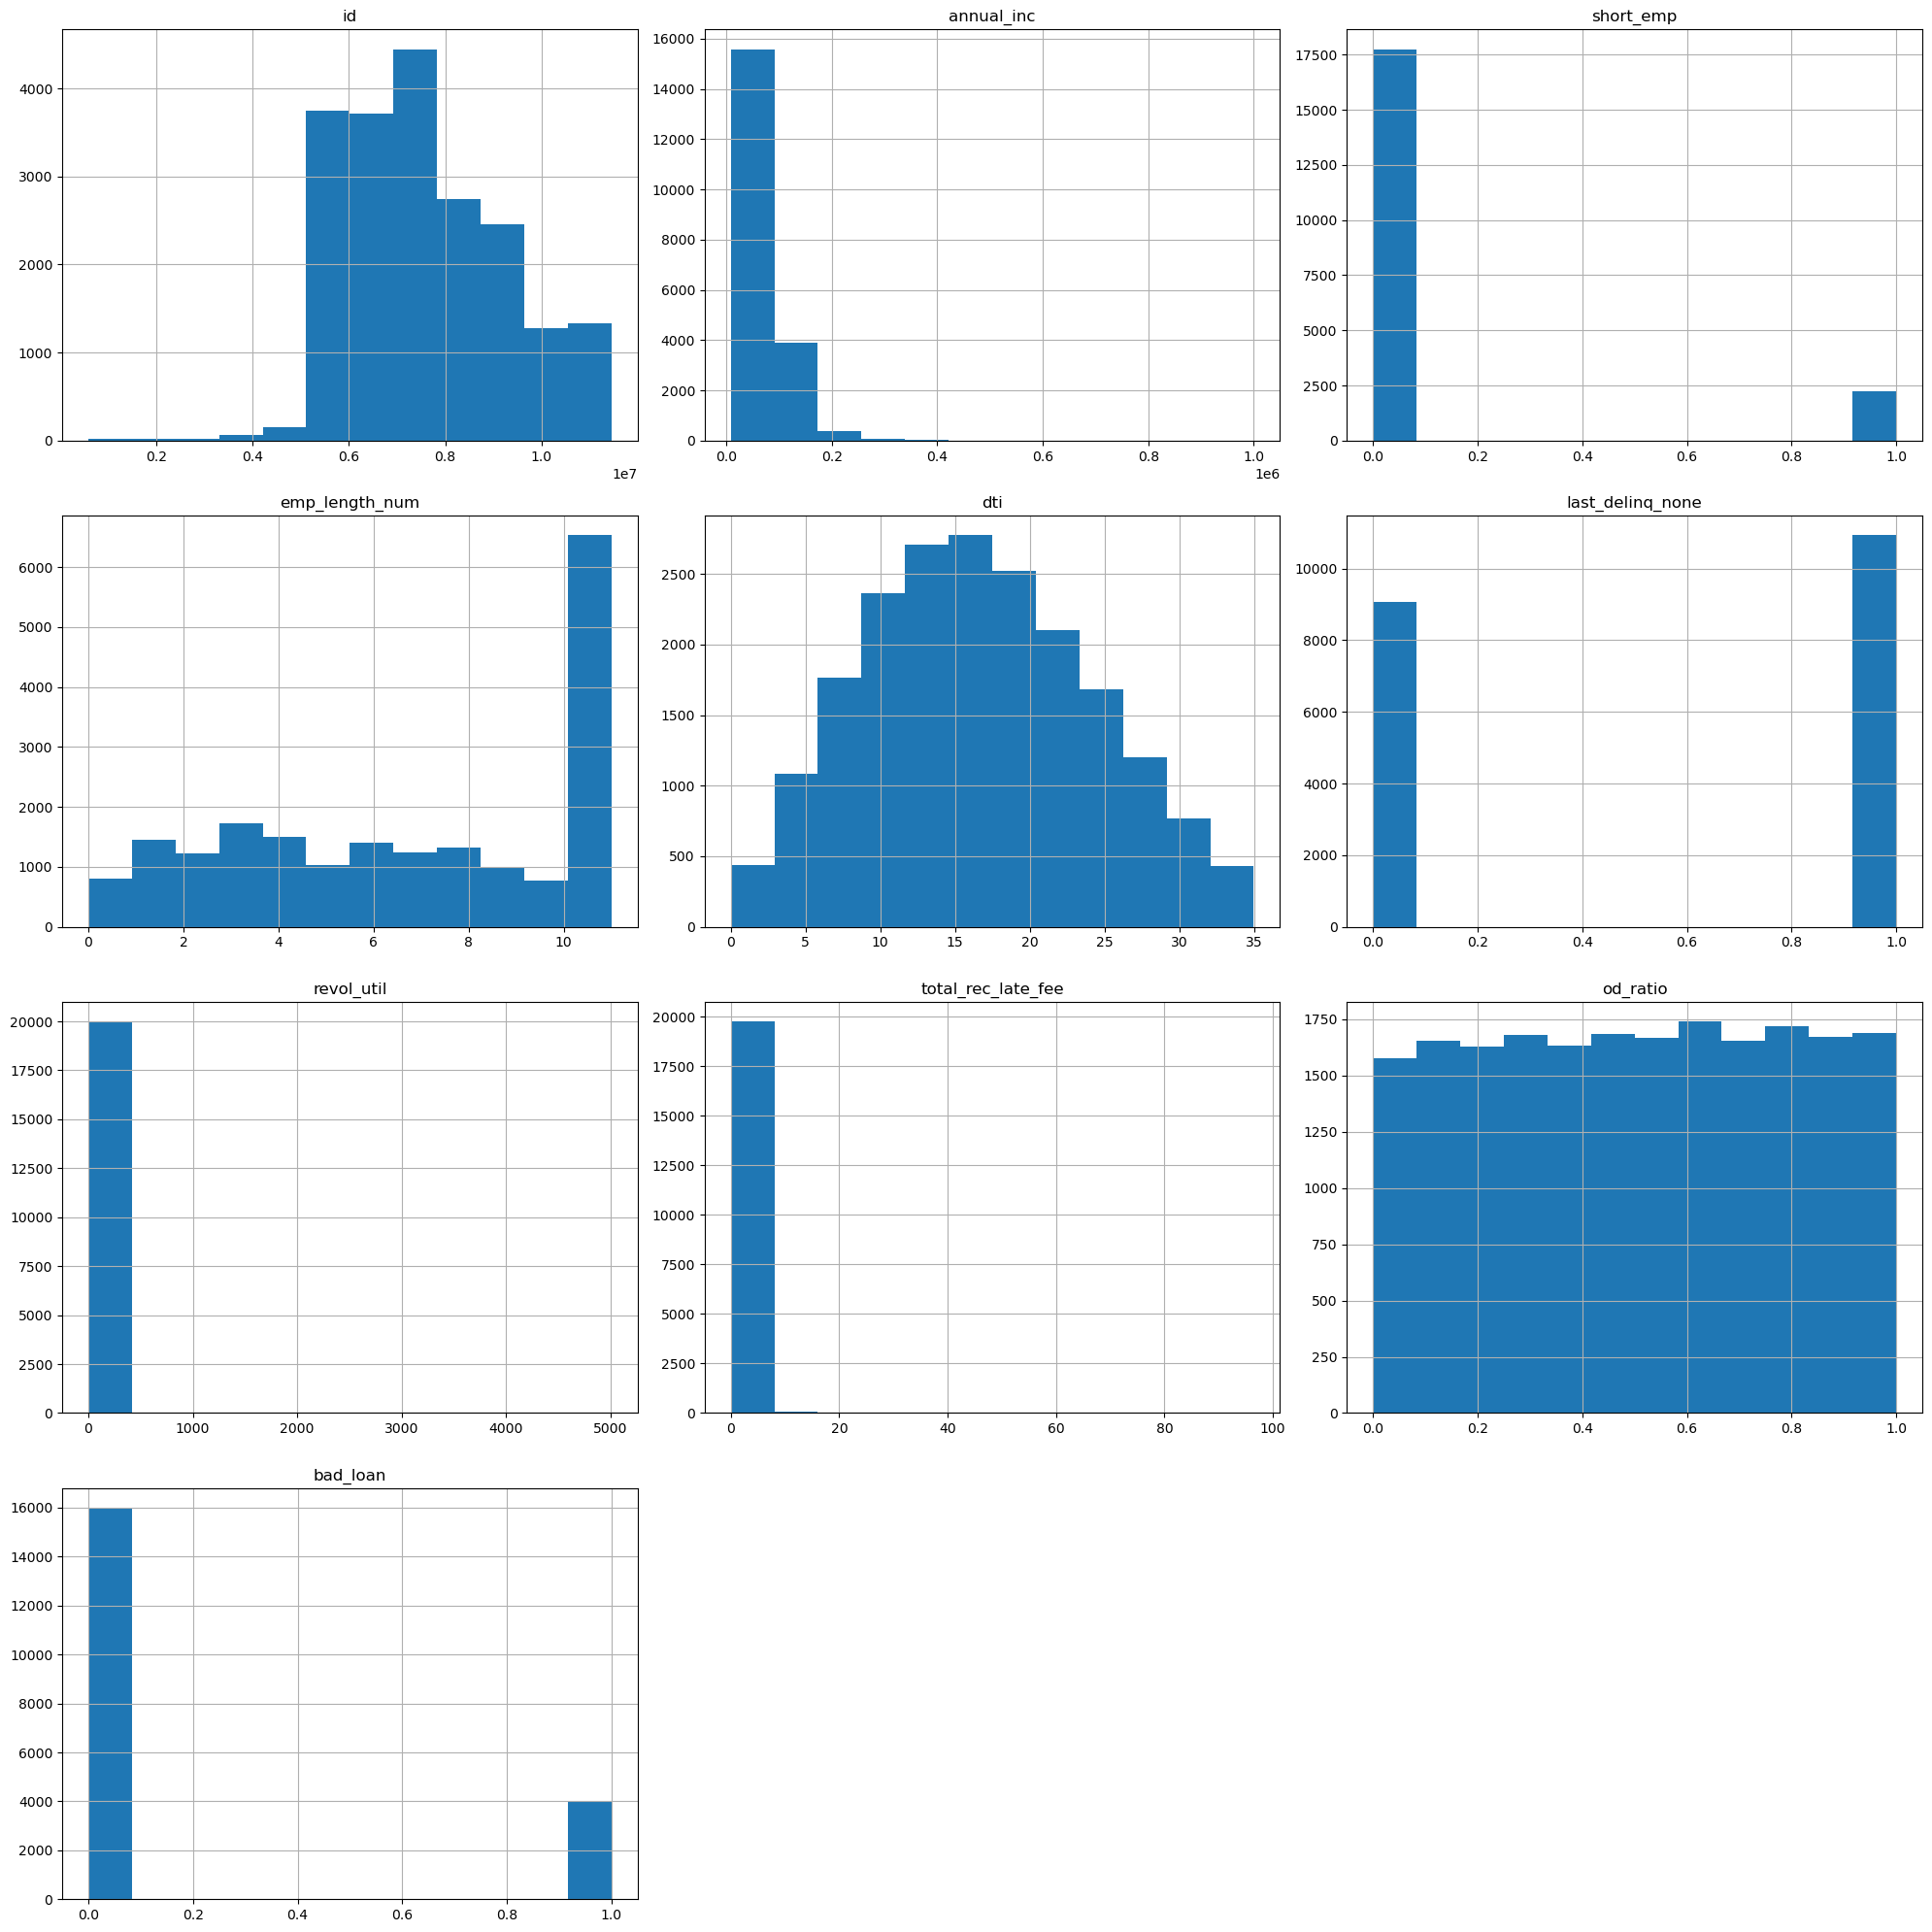

In [30]:
data.hist(figsize = (20, 20), bins = 12)
plt.tight_layout()


plt.show()

## Visualization of Categorical Variables

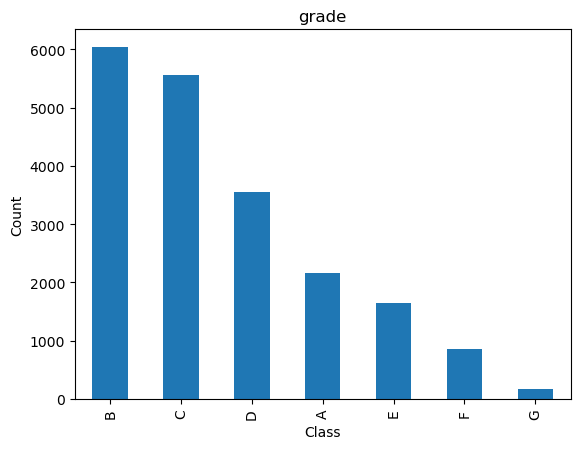

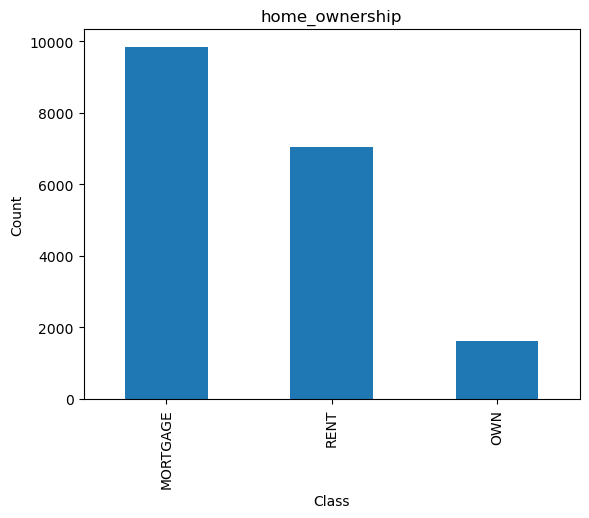

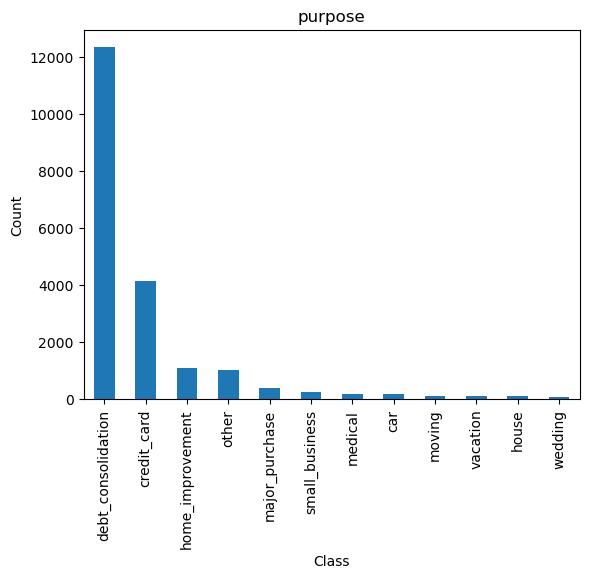

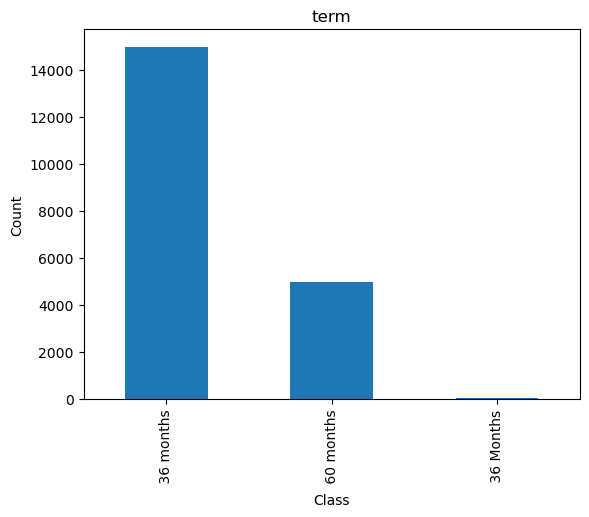

In [32]:
for col in data.select_dtypes(include = ["object"]).columns:
  data[col].value_counts().plot(kind = "bar")
  plt.xlabel("Class")
  plt.ylabel("Count")
  plt.title(col)
  plt.show()

It seems there is a typo in the '36 months' class on the variable 'term'.Fixed it by lowering the capitized characters.

In [34]:
data.term = data.term.str.lower()
data.term.value_counts()

term
36 months    15001
60 months     4999
Name: count, dtype: int64

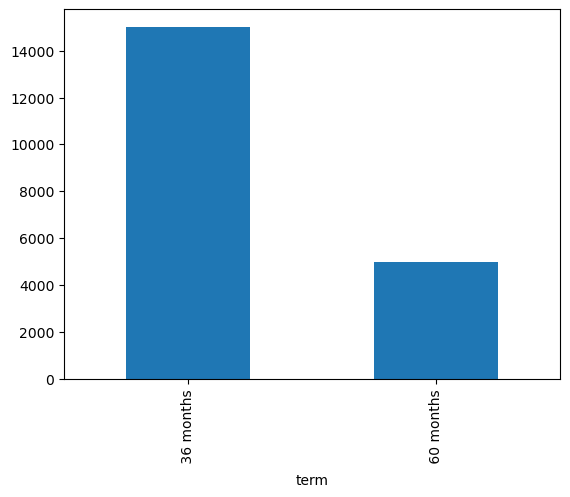

In [35]:
data["term"].value_counts().plot(kind = 'bar')
plt.show()

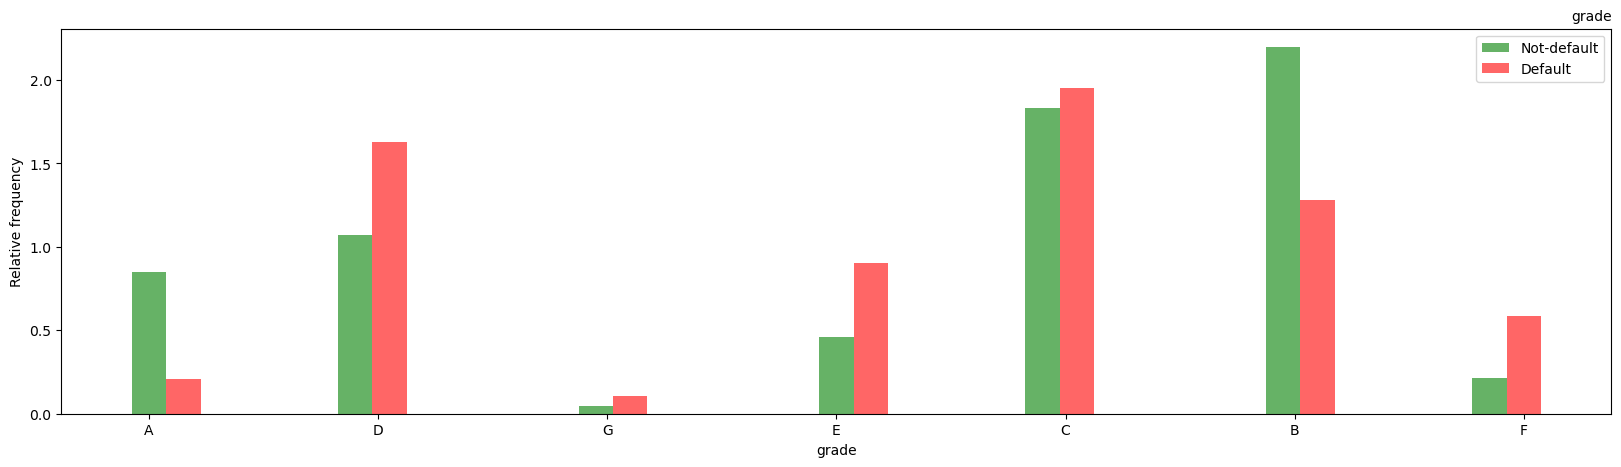

In [36]:
target("grade")

It is between the upper-grade classes that the highest not-default loans happen.

**Feature: annual_inc**
The self-reported annual income provided by the borrower during registration.

In [39]:
sns.distplot(data['annual_inc'])




<Axes: xlabel='annual_inc', ylabel='Density'>

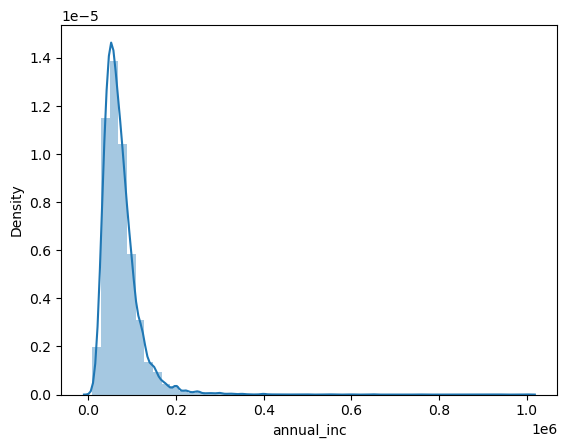

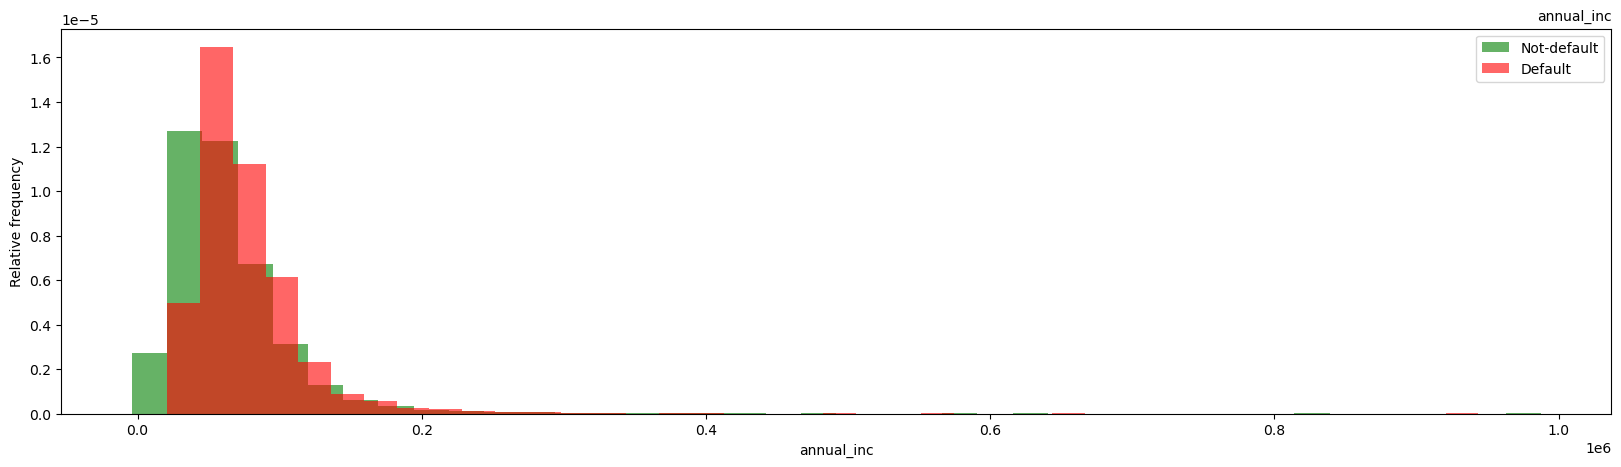

In [40]:
target("annual_inc") # here the two are overlapping and then a new color is also emrging .

**Feature: short_emp**
1 when emplyed for 1 year or less

In [42]:
data['short_emp'].value_counts().plot(kind = 'bar')

<Axes: xlabel='short_emp'>

The clients that have been employed for one or less years(instance 1) represent 11.23% data

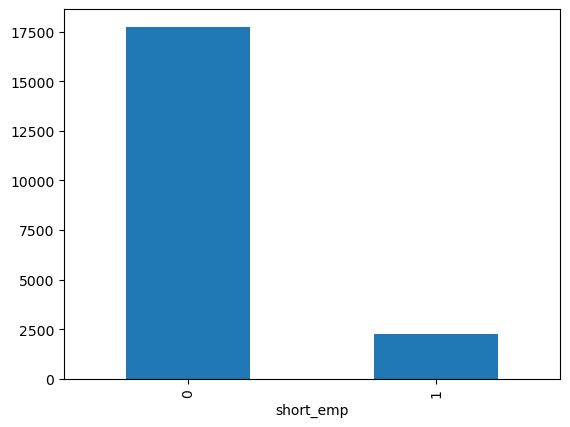

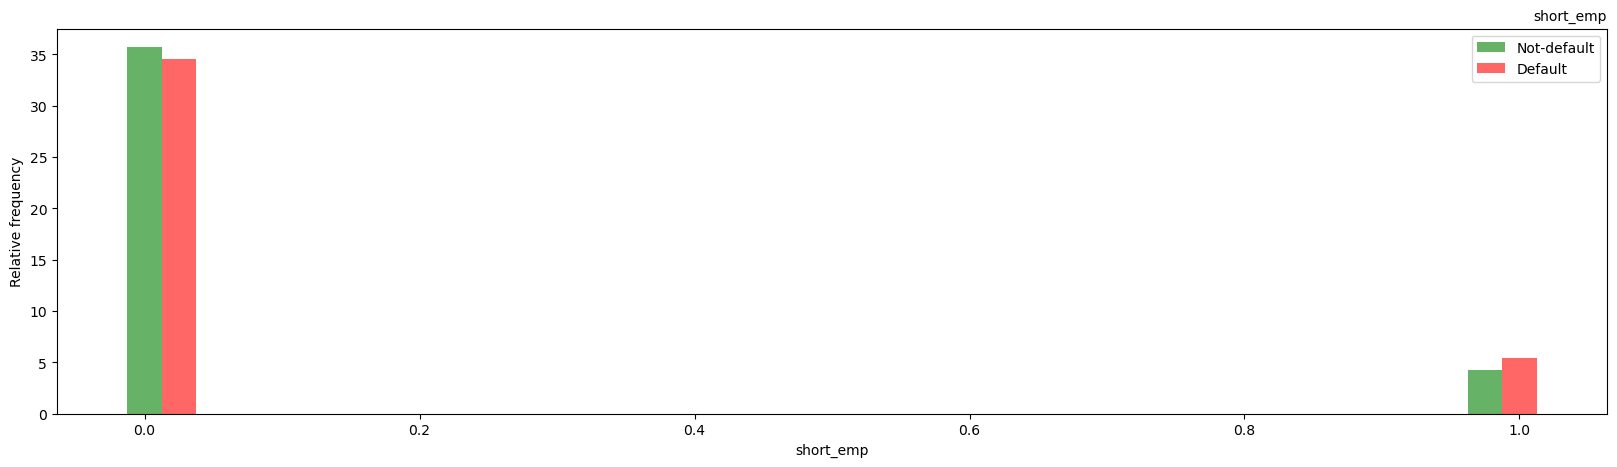

In [44]:
target("short_emp")

The segment emplyed for less than 1 year had loans on default more frequently than the other segment.

**Feature: emp_length_num**
Emplyment length in years. Possible values are between 0 and 10 where 0 means less than 1 year and 10 means 10 or more years.

In [47]:
sns.distplot(data['emp_length_num'])

<Axes: xlabel='emp_length_num', ylabel='Density'>

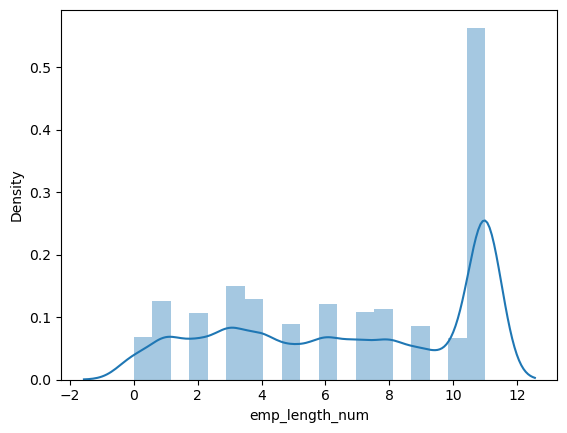

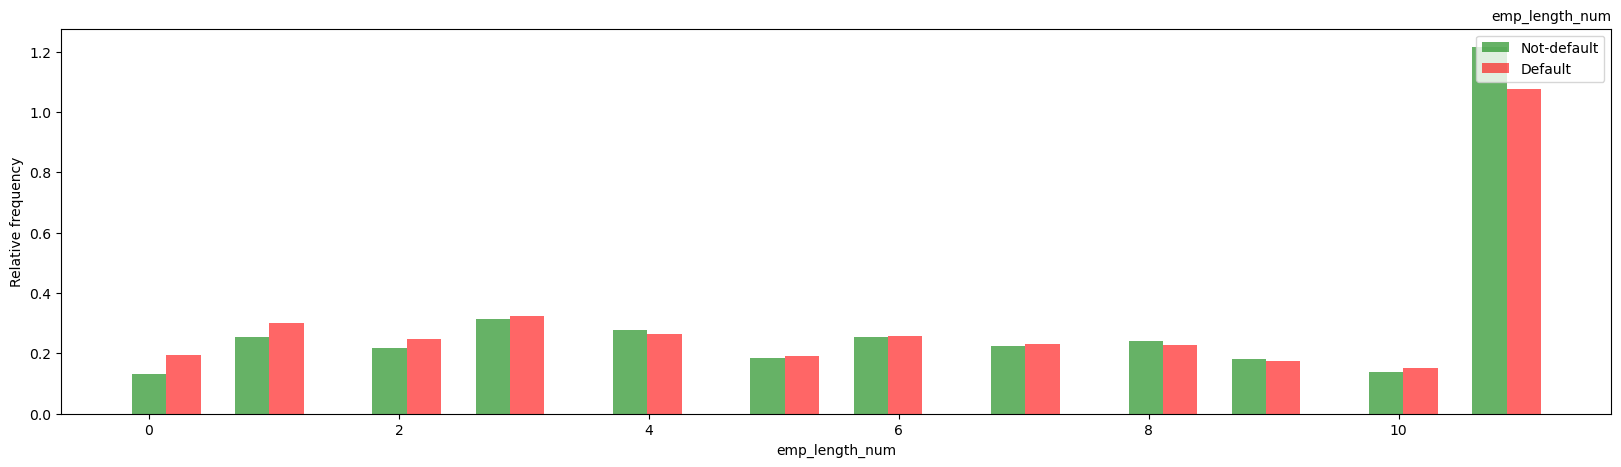

In [48]:
target("emp_length_num")

with a few exceptions, it's amongst nonstop employed clients for more than 10 years that the non-default loans occur.

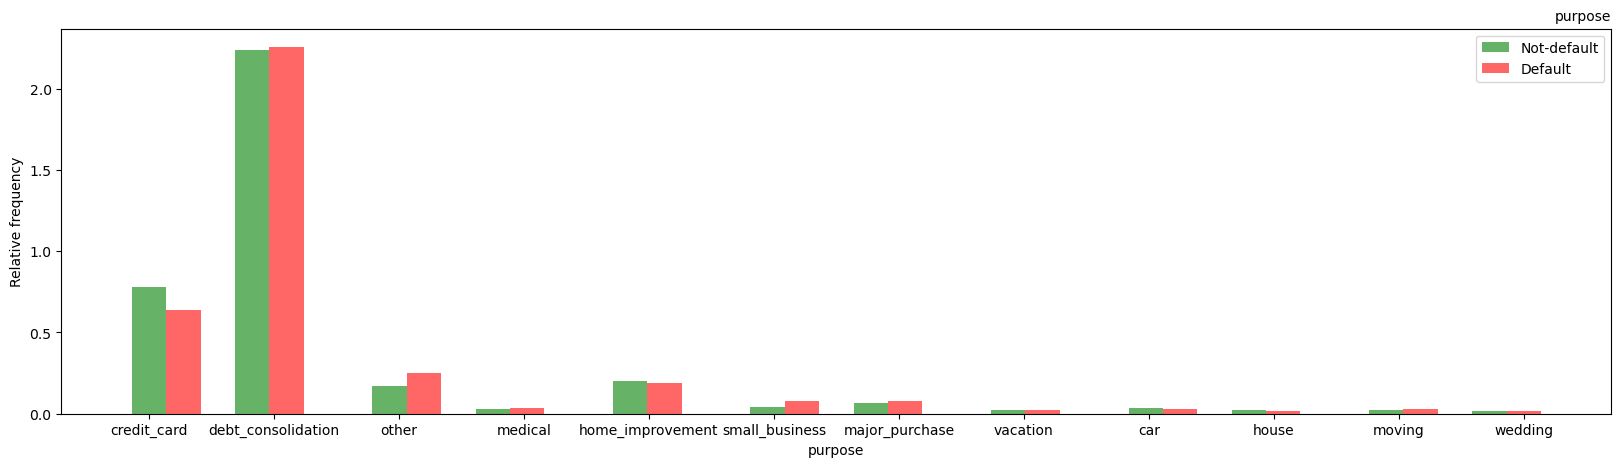

In [50]:
target("purpose")

wedding and vacation are the two purposes in which, on average, the majority of loans end up not been paid.

**Feature: home_ownership**
Type of home ownership

Proportionally, there is no major difference between the type of home ownership and the default loans.

**Feature: dti(debt to income)**
a ratio calculated using the borrower's total monthly debt payments on the total debt obligations, excluding mortage and requested LC loan, divided by the borrower's self reported monthly income.

In [55]:
sns.distplot(data['dti'])

<Axes: xlabel='dti', ylabel='Density'>

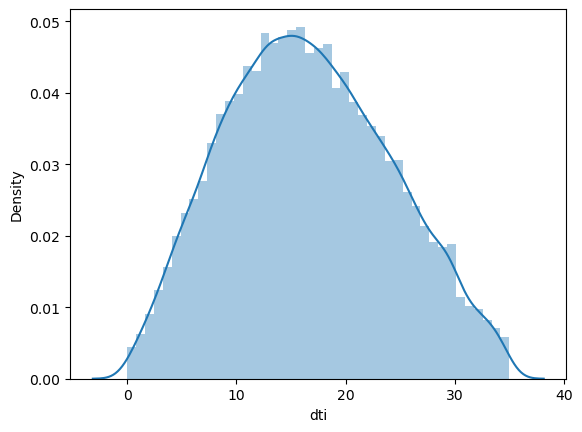

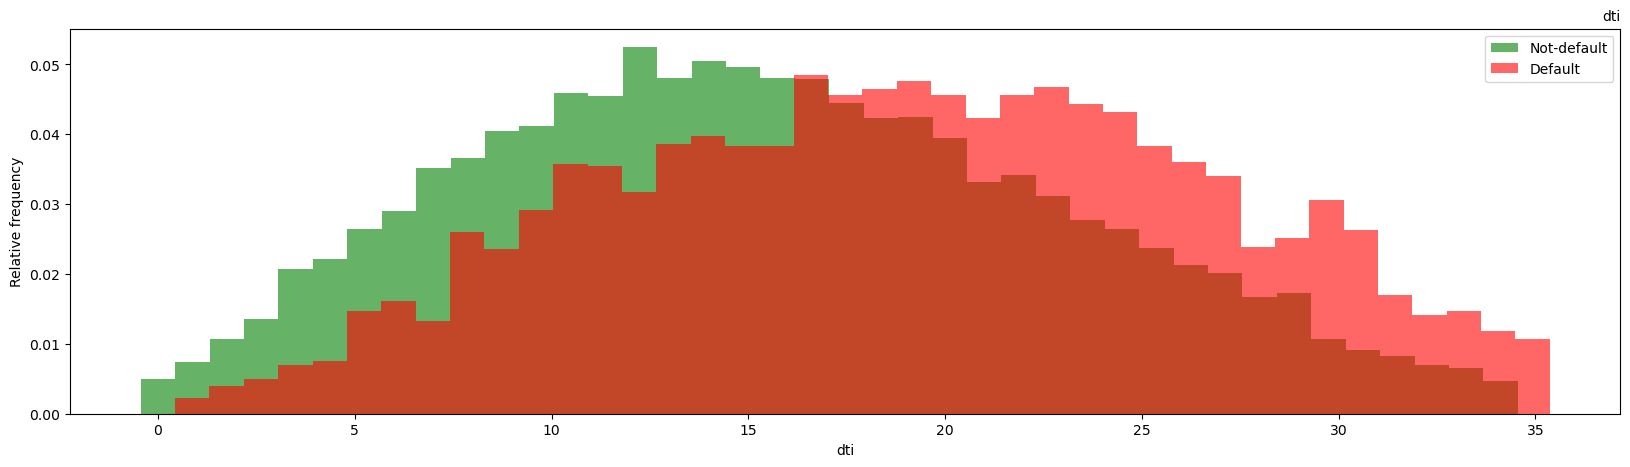

In [56]:
target("dti")

The distribution of bad loans(default) has, on average, higher 'dti' values in comparision with the good loans. The trend is: the higher the effort rate, the more frequently the loans on default.

**Feature: term**
The number of payments on the loan. Values are in months and can be either 36 or 60.

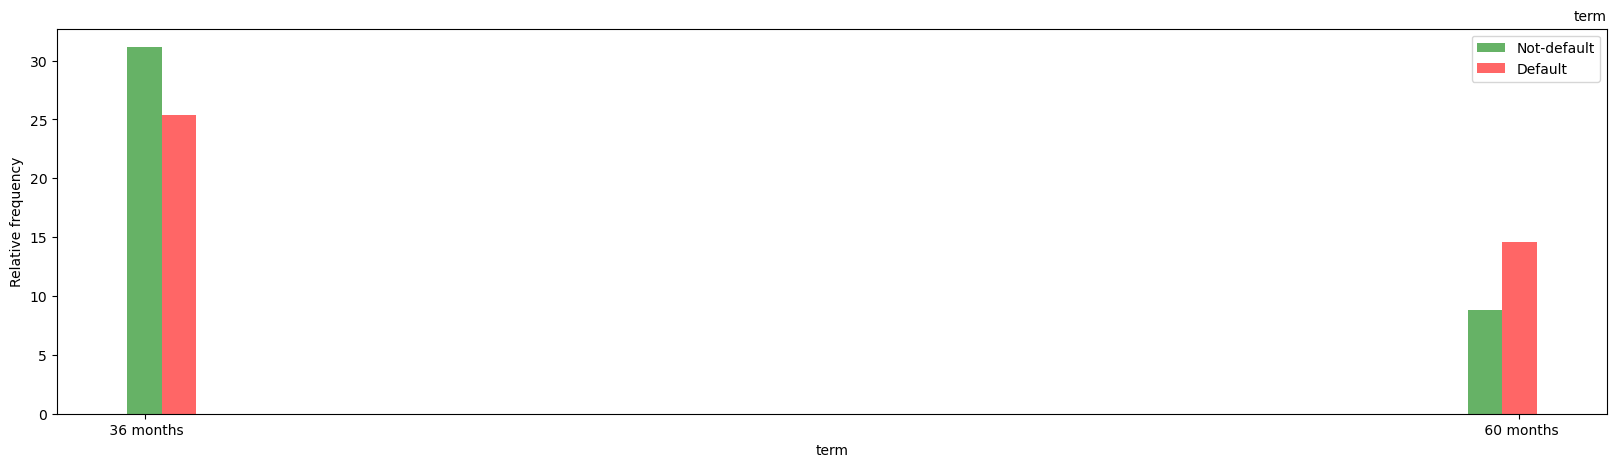

In [59]:
target("term")

Default loans occur inversly and more frequently over a 60 months term period.

In [61]:
sns.distplot(data["revol_util"])

<Axes: xlabel='revol_util', ylabel='Density'>

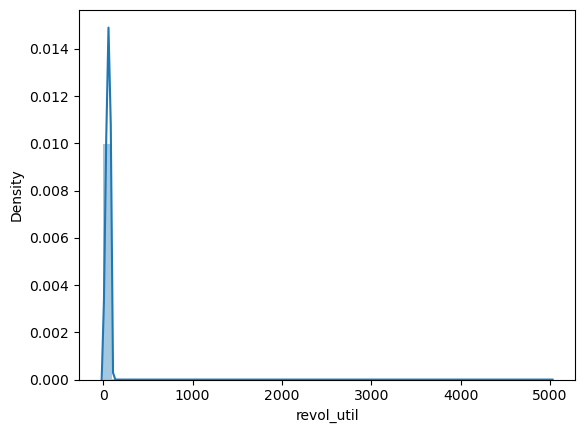

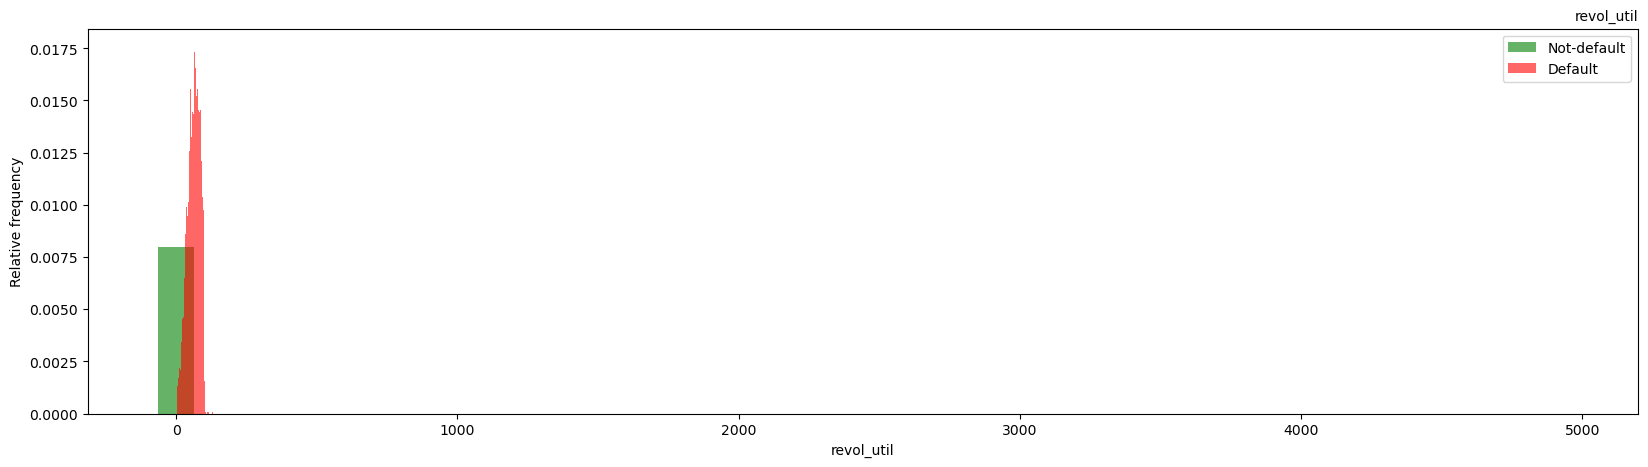

In [62]:
target("revol_util")

In [63]:
sns.distplot(data["total_rec_late_fee"])

<Axes: xlabel='total_rec_late_fee', ylabel='Density'>

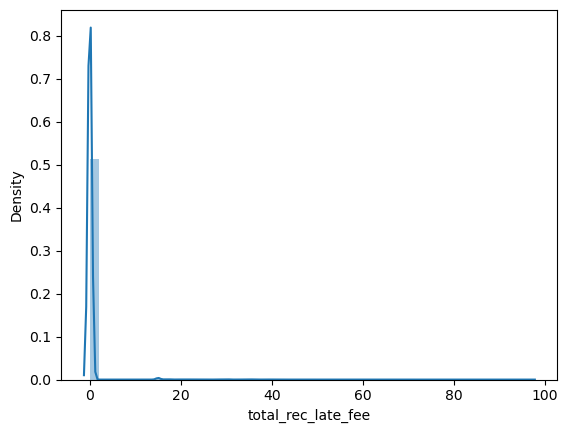

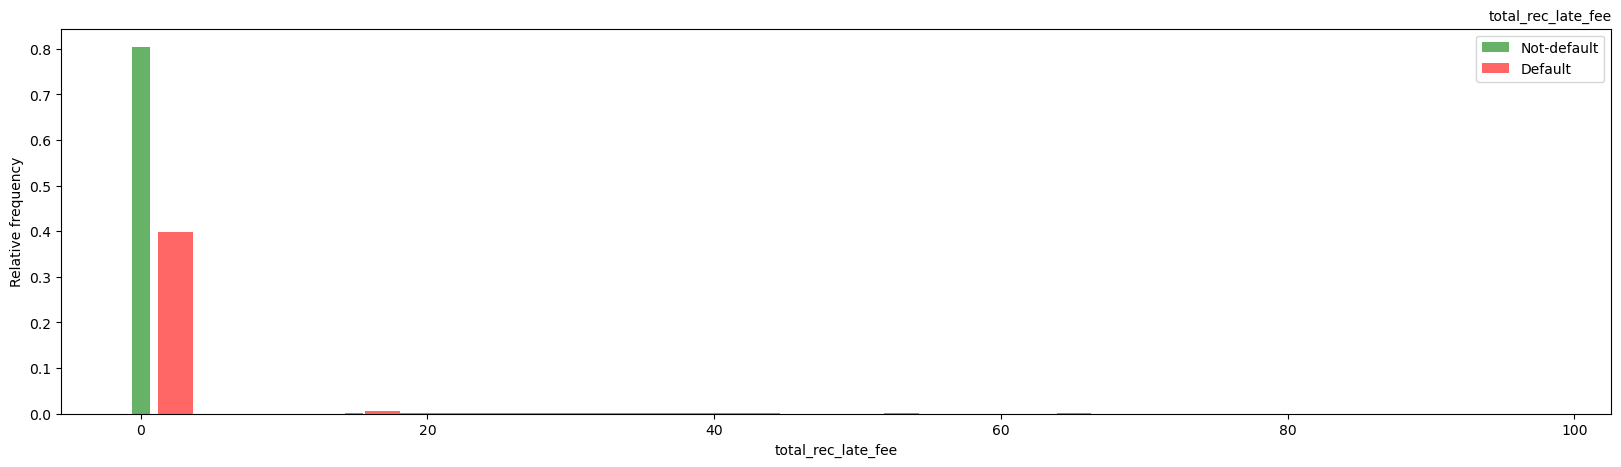

In [64]:
target("total_rec_late_fee")

In [65]:
sns.distplot(data["od_ratio"])

<Axes: xlabel='od_ratio', ylabel='Density'>

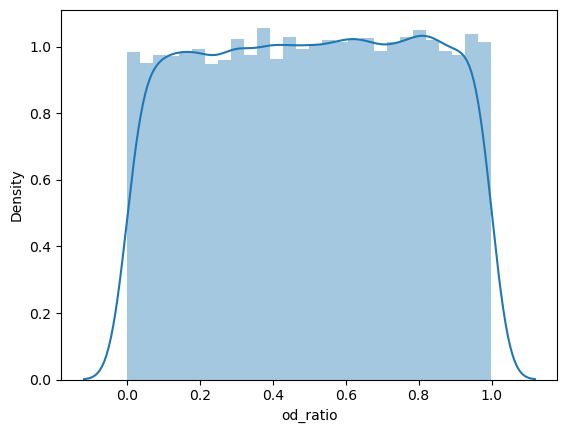

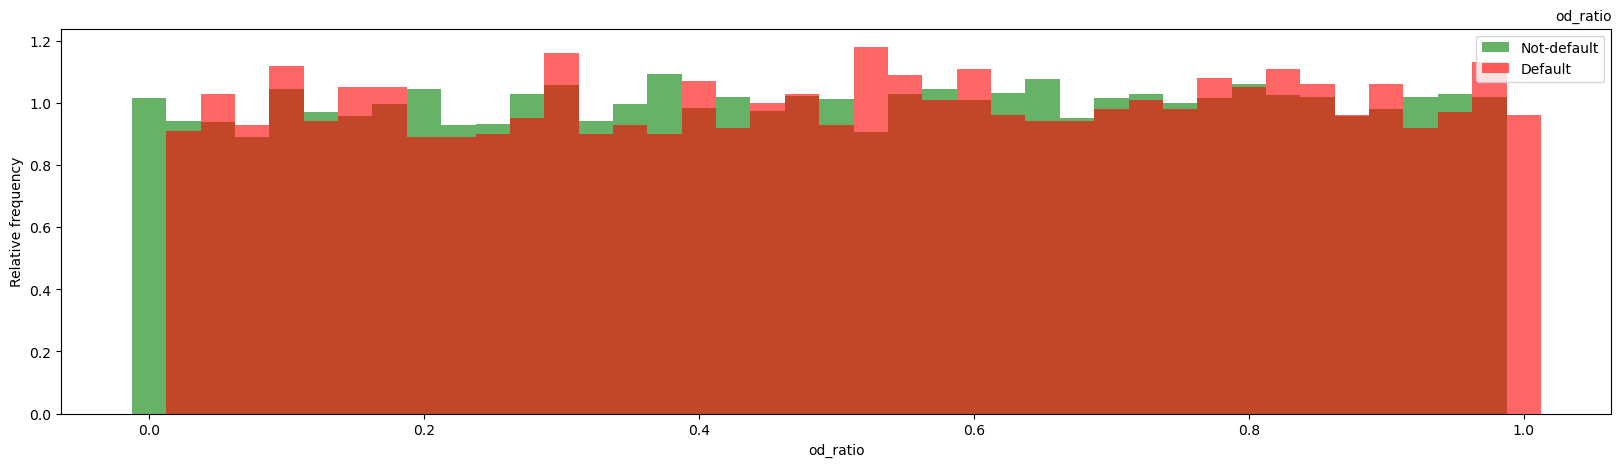

In [66]:
target("od_ratio")

In [67]:

data['last_delinq_none'].value_counts().plot(kind = 'bar')

<Axes: xlabel='last_delinq_none'>

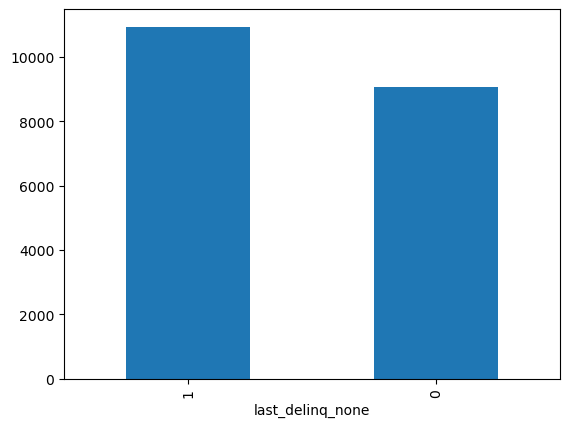

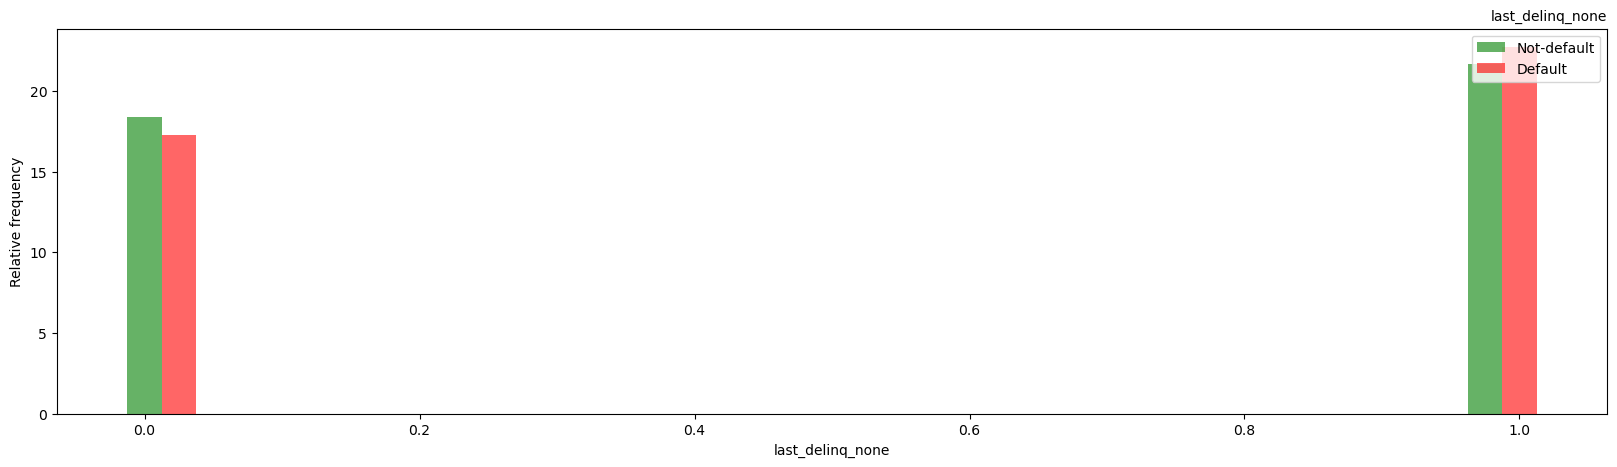

In [68]:
target('last_delinq_none')

## Correlations
Heatmap -> Pearson Method

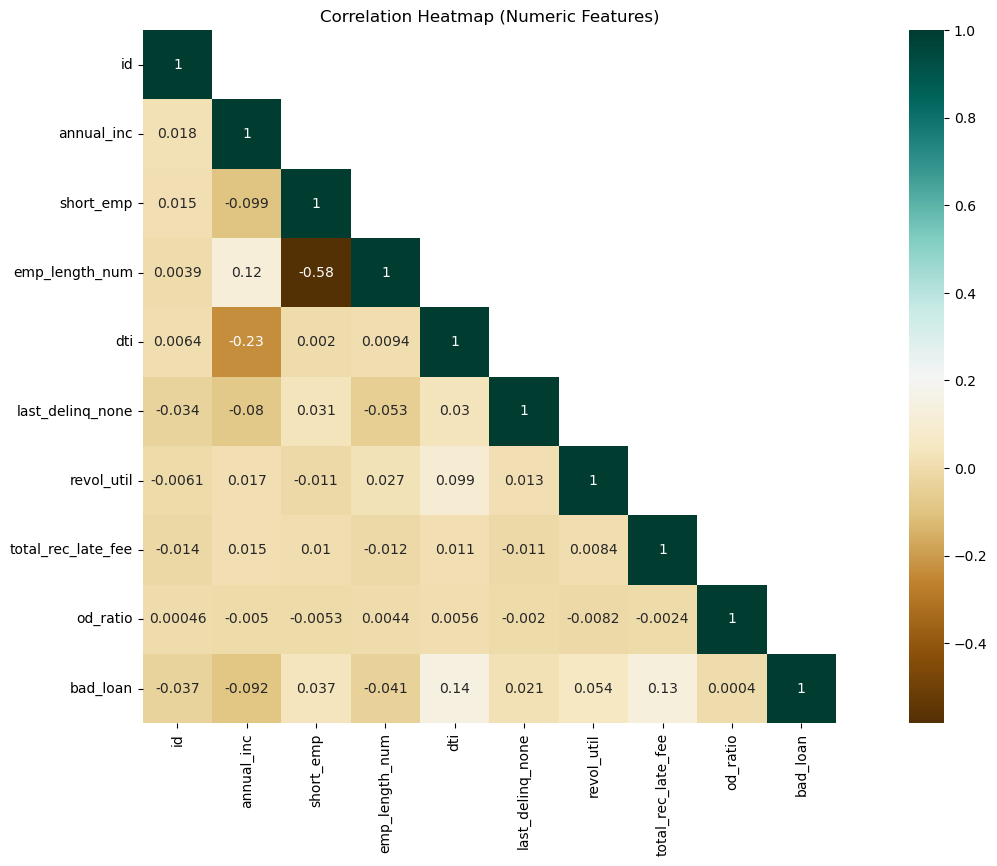

In [70]:
#corr=data.corr(numeric_only=True)
#mask = np.triu(corr, 1)
#plt.figure(figsize=(19, 9))
#sns.heatmap(data.corr(), annot=True, square=True, cmap='BrBG')
corr = data.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
plt.figure(figsize=(19, 9))
sns.heatmap(corr, annot=True, mask=mask, square=True, cmap='BrBG')
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


The heatmap shows there are some positive and negative correlations amongst variables.

Let's now find out which numerical features are the most correlated with the target.

The variable that is most correlated with the target is 'dti' with a weak and positive correlation of .14

# Data Wrangling: Cleansing and Feature Selection

#Handaling Outliers

Lets examine the data and check for any outliers.
Starting by selecting and filtering numeric and category data.

In [76]:
data_ca = data.select_dtypes(exclude=["int64","float64"]).copy()
data_nu = data.select_dtypes(exclude=["object","category"]).copy()

In [77]:
fig, axs = plt.subplots(ncols=2, nrows=5, figsize=(16, 16))
index = 0
axs = axs.flatten()
for k,v in data_nu.items():
    sns.boxplot(y=k, data=data_nu, ax=axs[index], orient="h")
    index += 1
    # plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)

In [78]:
# Dealing with the outliers through IQR score method
# Q1 = data['annual_inc'].quantile(0.25)
# Q3 = data['annual_inc'].quantile(0.75)
# IQR = Q3 - Q1
# data = data[((data['annual_inc'] > (Q1 - 1.5 * IQR)) &(data['annual_inc'] < (Q3 + 1.5 * IQR)))]

# value = data.revol_util.quantile([.99])
# p = value.iloc[0]
# data = data[data['annual_inc'] < p]

In [79]:
sns.boxplot( data=data["annual_inc"])

<Axes: ylabel='bad_loan'>

In [80]:
data.annual_inc.isnull().sum()

0

In [81]:
sns.boxplot(data = data['revol_util'])

<Axes: ylabel='bad_loan'>

In [82]:
Q1 = data['revol_util'].quantile(0.25)
Q3 = data['revol_util'].quantile(0.75)
IQR = Q3 - Q1
data = data[((data['revol_util'] > (Q1 - 1.5 * IQR)) &(data['revol_util'] < (Q3 + 1.5 * IQR)))]

In [83]:
# value = data.revol_util.quantile([.99999])
# p = value.iloc[0]
# data = data[data["revol_util"] < 100]

In [84]:
sns.boxplot( data=data["revol_util"])

<Axes: ylabel='bad_loan'>

In [85]:
value = data.total_rec_late_fee.quantile([.989])
p = value.iloc[0]
data = data[data["total_rec_late_fee"] < p]

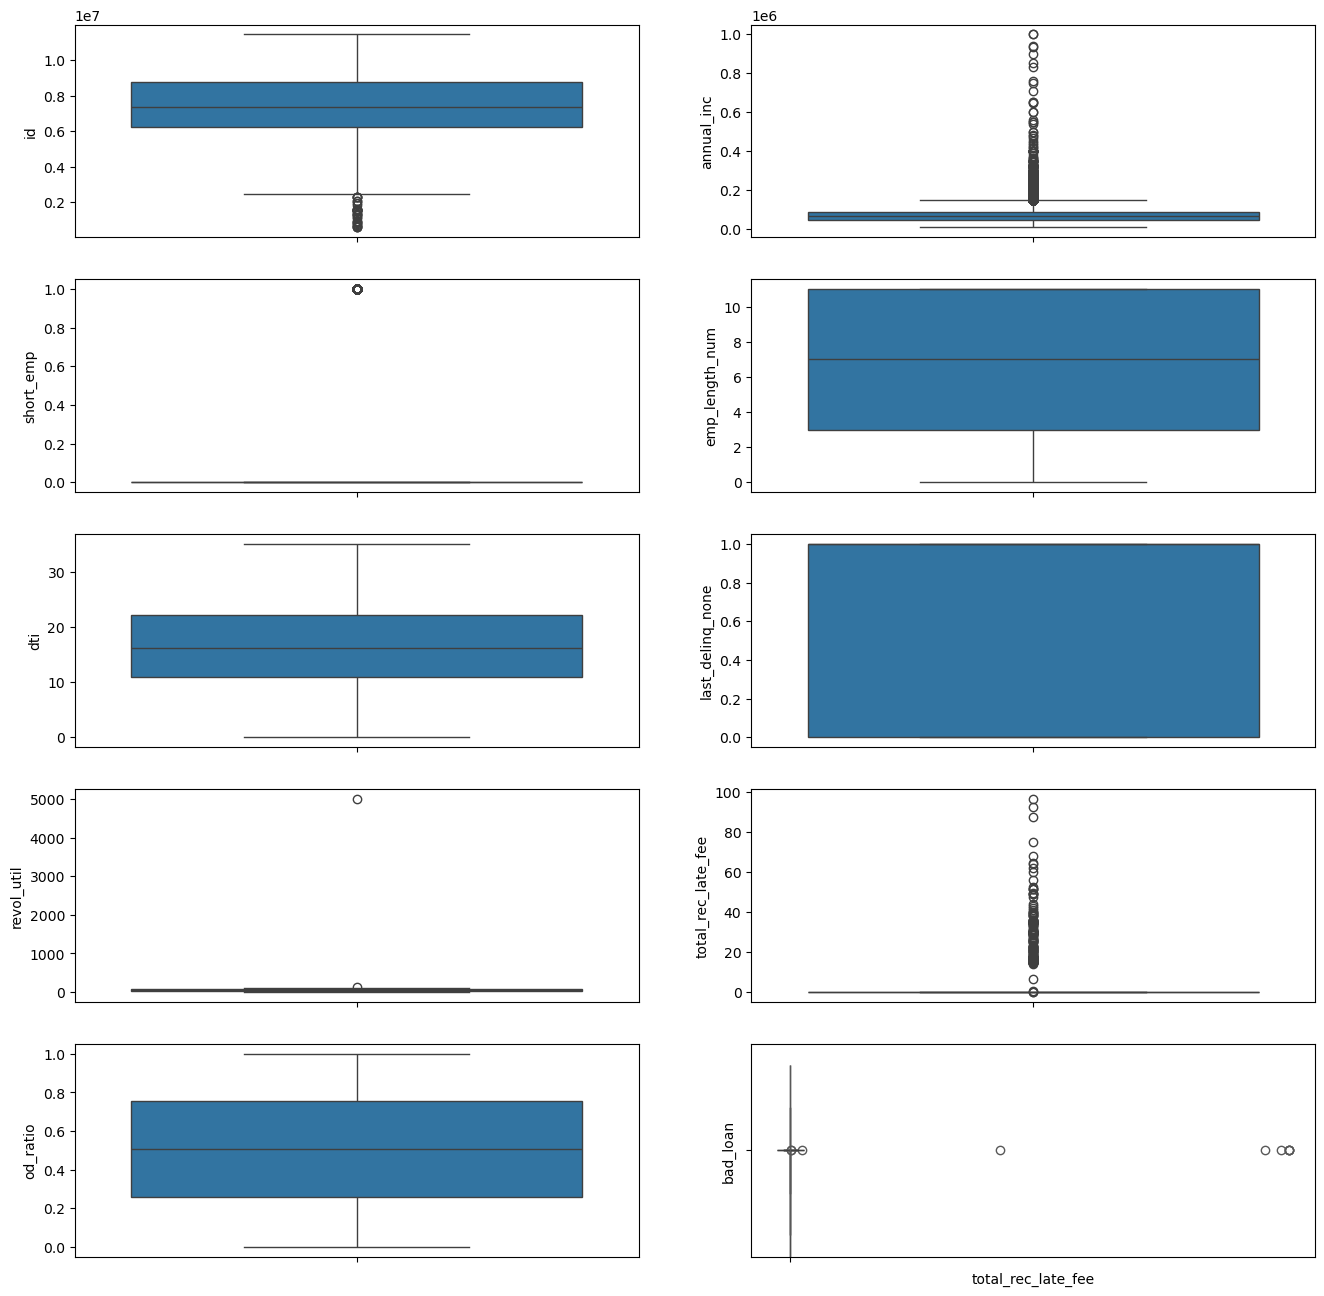

In [86]:
sns.boxplot(x=data['total_rec_late_fee'],data=data)
plt.xlabel('total_rec_late_fee', fontsize=10)
plt.show()

# Handling Missing Value

In [88]:
data["annual_inc"] = data.annual_inc.fillna(data.annual_inc.mean())

In [89]:
data["home_ownership"] = data.home_ownership.fillna(data.home_ownership.value_counts().index[0])
#select most frequent from home_ownership column and fill it in null places

In [90]:
data["dti"] = data.dti.fillna(data.dti.mean())

In [91]:
data.isnull().sum()

id                    0
grade                 0
annual_inc            0
short_emp             0
emp_length_num        0
home_ownership        0
dti                   0
purpose               0
term                  0
last_delinq_none      0
revol_util            0
total_rec_late_fee    0
od_ratio              0
bad_loan              0
dtype: int64

In [92]:
Xcat = data.select_dtypes(exclude=['int64','float64']).copy()
Xcat['target'] = data.bad_loan
Xcat.dropna(how="any", inplace=True)
ycat = Xcat.target
Xcat.drop("target", axis=1, inplace=True)
for col in Xcat.columns:


    
    table = pd.crosstab(Xcat[col], ycat)
    print()
    display(table)
    _, pval, _, expected_table = scipy.stats.chi2_contingency(table)
    print(f"p-value: {pval:.25f}")

target,0,1
grade,,
A,2030,120
B,5257,736
C,4375,1127
D,2565,947
E,1099,516
F,509,333
G,102,62


p-value: 0.0000000000000000000000000



target,0,1
home_ownership,,
MORTGAGE,9298,1922
OWN,1293,307
RENT,5346,1612


p-value: 0.0000000000000000000001839



target,0,1
purpose,,
car,138,30
credit_card,3424,679
debt_consolidation,9824,2386
home_improvement,881,199
house,85,12
major_purchase,289,83
medical,135,37
moving,92,28
other,744,261


p-value: 0.0000000000000802337614229



target,0,1
term,,
36 months,12415,2437
60 months,3522,1404


p-value: 0.0000000000000000000000000


In [93]:
data.drop("id", axis=1, inplace=True)

# Encoding

In [95]:
data["grade"] = data.grade.map({"A":7, "B":6, "C":5, "D":4, "E":3, "F":2, "G":1})

In [96]:
data = pd.get_dummies(data, columns=["term","home_ownership", "purpose"])

In [97]:
df = data

In [98]:
df.columns = [x.lower() for x in df.columns]

In [99]:
df.columns

Index(['grade', 'annual_inc', 'short_emp', 'emp_length_num', 'dti',
       'last_delinq_none', 'revol_util', 'total_rec_late_fee', 'od_ratio',
       'bad_loan', 'term_ 36 months', 'term_ 60 months',
       'home_ownership_mortgage', 'home_ownership_own', 'home_ownership_rent',
       'purpose_car', 'purpose_credit_card', 'purpose_debt_consolidation',
       'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase',
       'purpose_medical', 'purpose_moving', 'purpose_other',
       'purpose_small_business', 'purpose_vacation', 'purpose_wedding'],
      dtype='object')

In [100]:
df.dtypes

grade                           int64
annual_inc                    float64
short_emp                       int64
emp_length_num                  int64
dti                           float64
last_delinq_none                int64
revol_util                    float64
total_rec_late_fee            float64
od_ratio                      float64
bad_loan                        int64
term_ 36 months                  bool
term_ 60 months                  bool
home_ownership_mortgage          bool
home_ownership_own               bool
home_ownership_rent              bool
purpose_car                      bool
purpose_credit_card              bool
purpose_debt_consolidation       bool
purpose_home_improvement         bool
purpose_house                    bool
purpose_major_purchase           bool
purpose_medical                  bool
purpose_moving                   bool
purpose_other                    bool
purpose_small_business           bool
purpose_vacation                 bool
purpose_wedd

In [101]:
df.shape

(19778, 27)

#Handling Imbalanced Dataset

In [103]:
df['bad_loan'].value_counts()

bad_loan
0    15937
1     3841
Name: count, dtype: int64

In [105]:
df_train = df.copy()
from imblearn.over_sampling import SMOTE
# Resampling the minority class. The strategy can be changed as required.
sm = SMOTE(sampling_strategy='minority', random_state=42)
# Fit the model to generate the data.
oversampled_X, oversampled_Y = sm.fit_resample(df_train.drop('bad_loan', axis=1), df_train['bad_loan'])
oversampled = pd.concat([pd.DataFrame(oversampled_Y), pd.DataFrame(oversampled_X)], axis=1)

In [106]:
oversampled.shape

(31874, 27)

# Applying Models

In [108]:
df_lr = oversampled.copy()
# Dividing the dataset in train (80%) and test (20%)
train_set_lr, test_set_lr = train_test_split(df_lr, test_size = 0.2, random_state = seed)
X_train_lr = train_set_lr.drop(['bad_loan'], axis = 1)
y_train_lr = train_set_lr['bad_loan']
X_test_lr = test_set_lr.drop(['bad_loan'], axis = 1)
y_test_lr = test_set_lr['bad_loan']
# Normalizing the train and test data
scaler_lr = MinMaxScaler()
features_names = X_train_lr.columns
X_train_lr = scaler_lr.fit_transform(X_train_lr)
X_train_lr = pd.DataFrame(X_train_lr, columns = features_names)
X_test_lr = scaler_lr.transform(X_test_lr)
X_test_lr = pd.DataFrame(X_test_lr, columns = features_names)


In [109]:
lr=LogisticRegression(class_weight='balanced')
lr.fit(X_train_lr,y_train_lr)

LogisticRegression(class_weight='balanced')

In [110]:
from sklearn.metrics import roc_auc_score,confusion_matrix,classification_report

In [111]:
y_test_pred_lr=lr.predict(X_test_lr)

In [112]:
print(classification_report(y_test_lr,y_test_pred_lr))

              precision    recall  f1-score   support

           0       0.77      0.96      0.86      3179
           1       0.95      0.72      0.82      3196

    accuracy                           0.84      6375
   macro avg       0.86      0.84      0.84      6375
weighted avg       0.86      0.84      0.84      6375



In [113]:
print(f1_score(y_test_lr,y_test_pred_lr))

0.8185864340395229


In [114]:
important_features = pd.DataFrame(data = abs(lr.coef_.T), index = X_train_lr.columns, columns = ["value"])
important_features.sort_values(by = "value", ascending = False)

,value
annual_inc,5.363438
home_ownership_rent,5.354507
term_ 60 months,5.294276
term_ 36 months,5.201955
home_ownership_mortgage,5.175568
home_ownership_own,4.881606
purpose_small_business,4.554590
purpose_debt_consolidation,4.518535
purpose_home_improvement,4.479024
purpose_major_purchase,4.470381


In [115]:
from sklearn import metrics

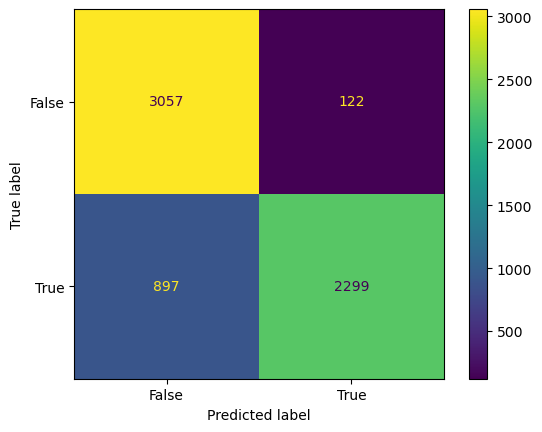

In [116]:
confusion_matrix = metrics.confusion_matrix(y_test_lr, y_test_pred_lr)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])

cm_display.plot()
plt.show()

In [117]:
from sklearn import svm
df_svm = oversampled.copy()
train_set_svc, test_set_svc = train_test_split(df_svm, test_size = 0.2, random_state = seed)
X_train_svc = train_set_svc.drop(['bad_loan'], axis = 1)
y_train_svc = train_set_svc['bad_loan']
X_test_svc = test_set_svc.drop(['bad_loan'], axis = 1)
y_test_svc = test_set_svc['bad_loan']
zscore_svc = StandardScaler()
features_names = X_train_svc.columns
X_train_svc = zscore_svc.fit_transform(X_train_svc)
X_train_svc = pd.DataFrame(X_train_svc, columns = features_names)
X_test_svc = zscore_svc.transform(X_test_svc)
X_test_svc = pd.DataFrame(X_test_svc, columns = features_names)

svc = SVC( class_weight='balanced')

In [118]:
svc.fit(X_train_svc,y_train_svc)
y_test_pred_clf=svc.predict(X_test_svc)
print(classification_report(y_test_svc,y_test_pred_clf))

              precision    recall  f1-score   support

           0       0.76      0.99      0.86      3179
           1       0.98      0.70      0.81      3196

    accuracy                           0.84      6375
   macro avg       0.87      0.84      0.84      6375
weighted avg       0.87      0.84      0.84      6375



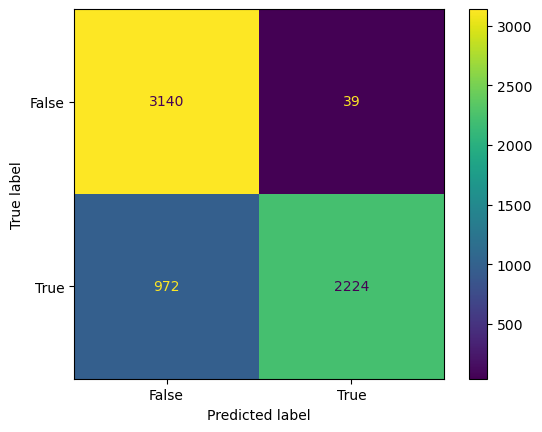

In [119]:
confusion_matrix = metrics.confusion_matrix(y_test_svc, y_test_pred_clf)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])

cm_display.plot()
plt.show()

In [120]:
print(f1_score(y_test_svc, y_test_pred_clf))

0.8148012456493864


In [121]:
df_trees = oversampled.copy()
train_set_dt, test_set_dt = train_test_split(df_trees, test_size = 0.2, random_state = seed)
X_train_dt = train_set_dt.drop(['bad_loan'], axis = 1)
y_train_dt = train_set_dt['bad_loan']
X_test_dt = test_set_dt.drop(['bad_loan'], axis = 1)
y_test_dt = test_set_dt['bad_loan']
clf_tree = tree.DecisionTreeClassifier( max_depth = 10).fit(X_train_dt, y_train_dt)
y_test_pred_dt=clf_tree.predict(X_test_dt)
print(classification_report(y_test_dt, y_test_pred_dt))

              precision    recall  f1-score   support

           0       0.77      0.87      0.82      3179
           1       0.85      0.75      0.80      3196

    accuracy                           0.81      6375
   macro avg       0.81      0.81      0.81      6375
weighted avg       0.81      0.81      0.81      6375



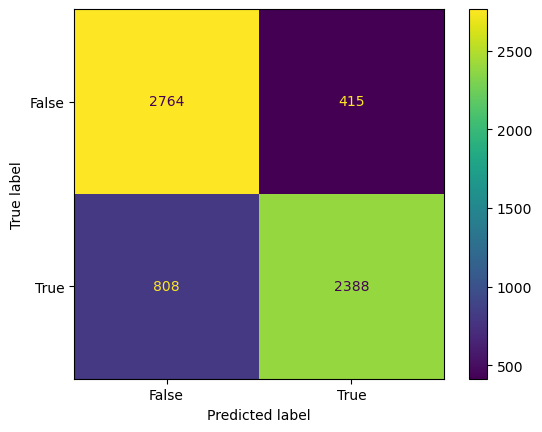

In [122]:
confusion_matrix = metrics.confusion_matrix(y_test_dt, y_test_pred_dt)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])

cm_display.plot()
plt.show()

In [123]:
print(f1_score(y_test_dt, y_test_pred_dt))

0.7961326887814636


In [124]:
df_rf = oversampled.copy()
train_set_rf, test_set_rf = train_test_split(df_rf, test_size = 0.2, random_state = seed)
X_train_rf = train_set_rf.drop(['bad_loan'], axis = 1)
y_train_rf = train_set_rf['bad_loan']
X_test_rf = test_set_rf.drop(['bad_loan'], axis = 1)
y_test_rf = test_set_rf['bad_loan']
rf = RandomForestClassifier(n_estimators = 100,  class_weight = None).fit(X_train_rf, y_train_rf)
y_test_pred_rf=rf.predict(X_test_rf)
print(classification_report(y_test_rf, y_test_pred_rf))


              precision    recall  f1-score   support

           0       0.82      0.93      0.87      3179
           1       0.92      0.79      0.85      3196

    accuracy                           0.86      6375
   macro avg       0.87      0.86      0.86      6375
weighted avg       0.87      0.86      0.86      6375



In [125]:
y_train_pred_rf=rf.predict(X_train_rf)
print(classification_report(y_train_rf, y_train_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12758
           1       1.00      1.00      1.00     12741

    accuracy                           1.00     25499
   macro avg       1.00      1.00      1.00     25499
weighted avg       1.00      1.00      1.00     25499



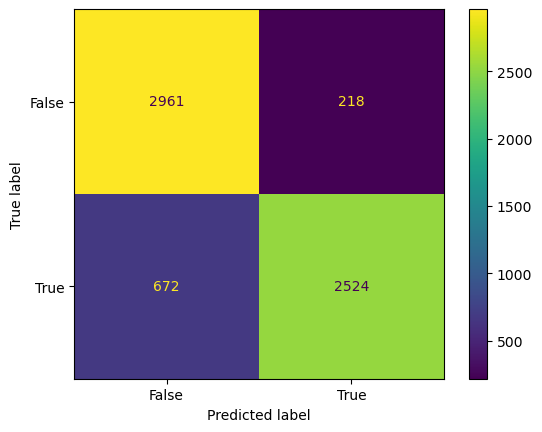

In [126]:
confusion_matrix = metrics.confusion_matrix(y_test_rf, y_test_pred_rf)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])

cm_display.plot()
plt.show()

In [127]:
print(f1_score(y_test_rf, y_test_pred_rf))

0.8501178848097002


In [128]:
# rf = RandomForestClassifier(random_state = seed, class_weight = None).fit(X_train_rf, y_train_rf)
# parameters = {'n_estimators':[10, 100, 300, 1000], 'min_samples_split' : [2, 5, 10], 'min_samples_leaf' :[1, 2, 4]}
# clf_rf = RandomizedSearchCV(rf, parameters, cv = 5).fit(X_train_rf, y_train_rf)
# y_test_pred_rf=rf.predict(X_test_rf)
# print(f1_score(y_test_rf, y_test_pred_rf))

In [129]:
rf = RandomForestClassifier(random_state = seed, class_weight = None).fit(X_train_rf, y_train_rf)
parameters = {'n_estimators':[10, 100, 300, 1000], 'min_samples_split' : [2, 5, 10], 'min_samples_leaf' :[1, 2, 4]}
clf_rf = RandomizedSearchCV(rf, parameters, cv = 5).fit(X_train_rf, y_train_rf)
# y_test_pred_rf=rf.predict(X_test_rf)

# Get the best estimator with the optimal hyperparameters
best_rf = clf_rf.best_estimator_

# Make predictions on the test set using the best model
y_test_pred_rf = best_rf.predict(X_test_rf)
print(f1_score(y_test_rf, y_test_pred_rf))

0.8534322820037106


In [130]:
import pickle

### Random Forest gave the best result with F1 score 0.85

In [132]:
pickle.dump(best_rf,open('rfmodel.pkl','wb'))

In [235]:
pickled_model=pickle.load(open('rfmodel.pkl','rb'))

## Making predictive System

In [281]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [283]:
# Load your dataset
df = pd.read_csv("tata_dataset.csv", low_memory=False)

# Drop irrelevant columns
df = df.drop(['last_major_derog_none', 'id'], axis=1)

# Encoding mapping for grade
df['grade'] = df['grade'].map({"A": 7, "B": 6, "C": 5, "D": 4, "E": 3, "F": 2, "G": 1})

# Define features and target
X = df.drop("bad_loan", axis=1)
y = df["bad_loan"]

# Identify categorical and numerical columns
categorical_cols = ["term", "home_ownership", "purpose"]
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.drop('grade').tolist() + ['grade']

In [285]:
# Preprocessing for numerical data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler())
])

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

In [287]:
# Full pipeline with SMOTE and RandomForest
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(sampling_strategy='minority', random_state=42)),
    ('model', RandomForestClassifier(n_estimators=300, min_samples_split=2, min_samples_leaf=1, random_state=42))
])

# Train pipeline
pipeline.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['annual_inc', 'short_emp',
                                                   'emp_length_num', 'dti',
                                                   'last_delinq_none',
                                                   'revol_util',
                                                   'total_rec_late_fee',
                                                   'od_ratio', 'grade']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['term', 'home_ownership',
                                                   'purpose'])])),
                ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
                ('model',
                 RandomForestClassifier(n_estimators=300, random_state=42))])

In [288]:
# Save pipeline
import joblib
joblib.dump(pipeline, "loan_default_pipeline.pkl")

['loan_default_pipeline.pkl']

In [306]:
# Predict on new data
new_data = pd.DataFrame({
    'grade': [1],
    'annual_inc': [100000],
    'short_emp': [1],
    'emp_length_num': [1],
    'home_ownership': ['RENT'],
    'dti': [26.27],
    'purpose': ['credit_card'],
    'term': ['36 months'],
    'last_delinq_none': [1],
    'revol_util': [43.2],
    'total_rec_late_fee': [0.0],
    'od_ratio': [0.1606240771977423]
})

#11454641,A,100000.0,1,1,RENT,26.27,credit_card, 36 months,1,,43.2,0.0,0.1606240771977423,0

prediction = pipeline.predict(new_data)
print("Prediction:", prediction)
if(prediction[0]==0):
    print("Borrower will not be a defaulter")
else: print("Defaulter")


Prediction: [1]
Defaulter
